In [ ]:
# SETUP
import os
import sys

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats
import wandb

# Import notebook utilities
from src.utils.nb_utils import *
from src.data.datasets import get_dataset
from src.sae import *  # Import all SAE analysis utilities

# Setup device and seeds
DEVICE = setup_notebook(seed=42)

# --- Configuration ---
MODEL_NAME = '2layer_100dig_64d'
SAE_NAME = "sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt" # MSE: 0.0042, Recon Acc: 0.8688 (old - not as high accuracy as below)

# Output Config
SAVE_RESULTS = False
SAVE_DIR = "../results/sae_results/" if SAVE_RESULTS else None

# --- Load Models ---
model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)

# Extract config for convenience
D_MODEL = model_cfg['d_model']
N_LAYERS = model_cfg['n_layers']
N_HEADS = model_cfg['n_heads']
LIST_LEN = model_cfg['list_len']
N_DIGITS = model_cfg['n_digits']
SEP_TOKEN_INDEX = model_cfg['sep_token_index']

# Load SAE
sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE = sae_cfg['dict_size']
TOP_K = sae_cfg['k']

# Load activation mean from checkpoint (for centering)
SAE_PATH = os.path.join('../results/sae_models', SAE_NAME)
sae_checkpoint = torch.load(SAE_PATH, map_location=DEVICE, weights_only=False)
act_mean = sae_checkpoint["act_mean"].to(DEVICE)

# Load validation dataset and collect SAE activations
train_ds, val_ds = get_dataset(
    n_digits=N_DIGITS,
    list_len=LIST_LEN,
    no_dupes=False,
    train_dupes_only=False
)
# concat both
all_ds = torch.utils.data.ConcatDataset([train_ds, val_ds])

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)
all_dl = DataLoader(all_ds, batch_size=128, shuffle=False)

# Collect SAE activations for ALL data (not getting acccuracy so it's fine to incl train)
d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model,
    sae=sae,
    val_dl=all_dl, 
    act_mean=act_mean,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

# get data for analysis

# Extract attention weights from SEP token to input positions
alpha_d1_all, alpha_d2_all = collect_attention_weights(
    model=model,
    dataloader=all_dl,
    sep_idx=SEP_TOKEN_INDEX,
    device=DEVICE
)

# Identify special features
special_features_info = identify_special_features(
    sae_acts_all=sae_acts_all,
    alpha_d1_all=alpha_d1_all,
    alpha_d2_all=alpha_d2_all,
    threshold=0.5
)

feature_firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
active_features = np.where(feature_firing_freq > 0)[0]
n_active = len(active_features)

# Sort by firing frequency
sorted_indices = np.argsort(feature_firing_freq)[::-1]
top_n = min(30, n_active)

/Users/Subspace_Explorer/Projects/list-comp-priv/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from /Users/Subspace_Explorer/Projects/list-comp-priv/models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded model from /Users/Subspace_Explorer/Projects/list-comp-priv/models/2layer_100dig_64d.pt
✓ Loaded SAE from /Users/Subspace_Explorer/Projects/list-comp-priv/results/sae_models/sae_d100_k3_lr0.0003_seed44_2layer_100dig_64d.pt
  - Dictionary size: 100
  - Top-K: 3


Feature 30 fires on 7054 / 10000 inputs


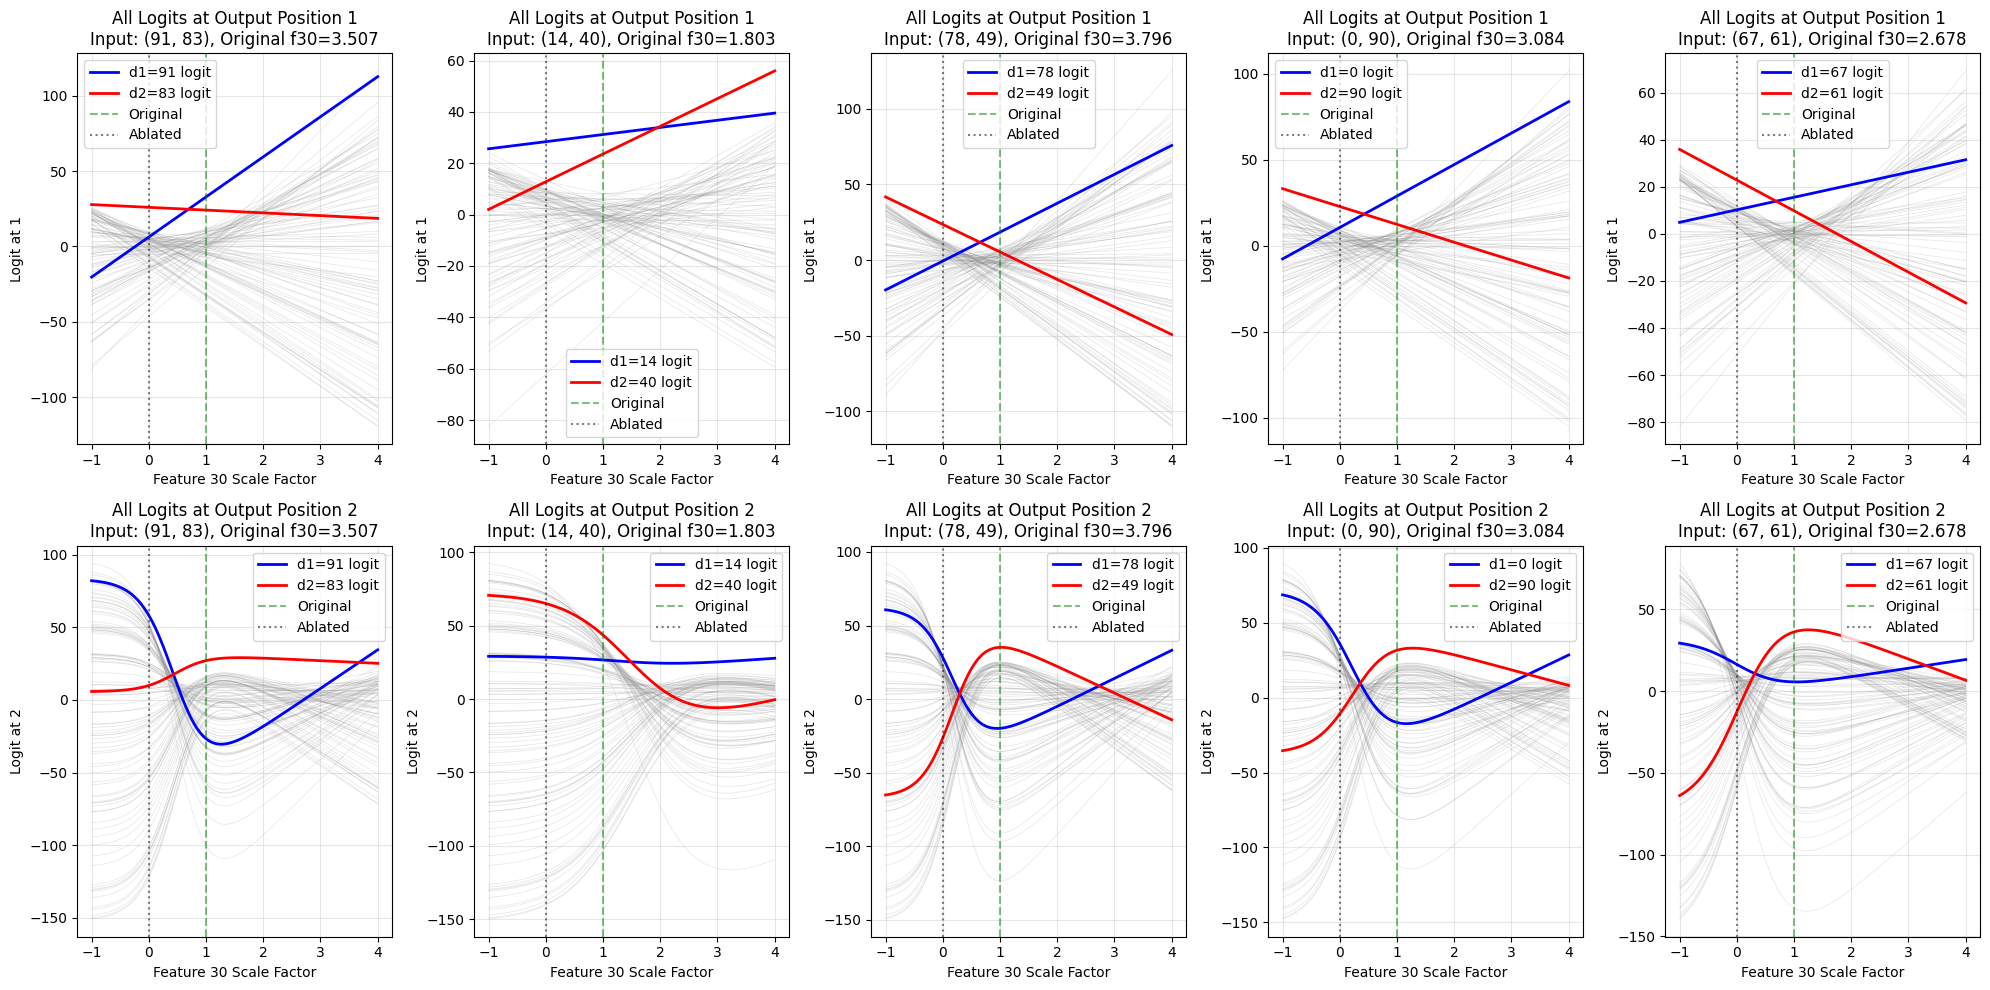

In [ ]:
# see rough results
SPECIAL_FEAT_IDX = 30

results=feature_steering_experiment(
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    save_dir=None
)

In [ ]:
# lets check how linear the logit lines are in the graph
def verify_linearity(results_list):
    """
    Evaluates linearity using R^2 and Maximum Residual Error.
    """
    from scipy.stats import linregress
    for i, res in enumerate(results_list):
        scales = res['scales']
        print(f"--- Input pair ({res['d1']}, res['d2']) ---")
        
        # Test targets
        targets = {
            'logit_d1_o1': res['logit_d1_o1'],
            'logit_d2_o1': res['logit_d2_o1'],
            'logit_d1_o2': res['logit_d1_o2'],
            'logit_d2_o2': res['logit_d2_o2']
        }
        
        for name, logits in targets.items():
            # Fit Ordinary Least Squares regression
            slope, intercept, r_value, p_value, std_err = linregress(scales, logits)
            r_squared = r_value ** 2
            
            # Calculate residuals (actual - predicted)
            predicted_logits = (slope * scales) + intercept
            max_residual = np.max(np.abs(logits - predicted_logits))
            
            # Formatting output
            is_linear = r_squared > 0.9999
            status = "STRAIGHT" if is_linear else "CURVED"
            
            print(f"  {name:11} -> {status} | R^2: {r_squared:.6f} | Max Residual: {max_residual:.2e}")
        print()

verify_linearity(results)

# TODO will need to do this for all inputs (not just these) for rigour in paper
# but I think it's pretty clear that the o1 position lines are straight, and o2 ones are curved

--- Input pair (91, res['d2']) ---
  logit_d1_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 1.19e-05
  logit_d2_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 3.04e-06
  logit_d1_o2 -> CURVED | R^2: 0.240024 | Max Residual: 4.99e+01
  logit_d2_o2 -> CURVED | R^2: 0.636181 | Max Residual: 8.15e+00

--- Input pair (14, res['d2']) ---
  logit_d1_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 3.94e-06
  logit_d2_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 4.35e-06
  logit_d1_o2 -> CURVED | R^2: 0.453514 | Max Residual: 3.02e+00
  logit_d2_o2 -> CURVED | R^2: 0.923263 | Max Residual: 2.04e+01

--- Input pair (78, res['d2']) ---
  logit_d1_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 5.89e-06
  logit_d2_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 5.67e-06
  logit_d1_o2 -> CURVED | R^2: 0.073454 | Max Residual: 3.67e+01
  logit_d2_o2 -> CURVED | R^2: 0.204474 | Max Residual: 4.10e+01

--- Input pair (0, res['d2']) ---
  logit_d1_o1 -> STRAIGHT | R^2: 1.000000 | Max Residual: 8.63e-06

In [ ]:
# TODO check what polynomial best fits the o2 lines (maybe quartic?) - good to include in paper

In [ ]:
# bisection for exact crossover points (to 3dp)

coarse_results = feature_steering_experiment(
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    plot=False,  # Don't plot since we're finding exact values
    scale_factors=np.linspace(0, 10, 20),  # Coarse sampling just to find regions
    save_dir=None
)

# Perform crossover analysis with bisection for exact values (using new refactored function)
from src.sae.steering import analyze_feature_crossovers

crossover_df = analyze_feature_crossovers(
    results=coarse_results,
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    device=DEVICE,
    verbose=True
)

Feature 30 fires on 7054 / 10000 inputs

CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (91, 83)
Original feature 30 activation: 3.5068
Original model output: (91, 83)

📍 O1: Found 1 crossover point(s)
   Crossover #1 at scale = 0.692 (3dp)
      d1 logit = 20.241, d2 logit = 24.969
      → Model output: (83, 83)

📍 O2: Found 2 crossover point(s)
   Crossover #1 at scale = 0.432 (3dp)
      d1 logit = 58.221, d2 logit = 9.928
      → Model output: (83, 91) SWAPPED!
   Crossover #2 at scale = 3.673 (3dp)
      d1 logit = 12.060, d2 logit = 26.712
      → Model output: (91, 83)

Test Case 2: Input (14, 40)
Original feature 30 activation: 1.8030
Original model output: (14, 40)

📍 O1: Found 1 crossover point(s)
   Crossover #1 at scale = 1.948 (3dp)
      d1 logit = 32.792, d2 logit = 29.835
      → Model output: (14, 14)

📍 O2: Found 2 crossover point(s)
   Crossover #1 at scale = 1.488 (3dp)
      d1 logit = 26.576, d2 logit = 41.896
      → Model output: (14, 40)
   Crossover #2 

In [ ]:
# What's the accuracy when special feature is ablated?
def evaluate_with_ablated_feature(
    model, sae, act_mean, feature_idx, 
    dataloader, layer_idx, sep_idx, n_digits, device
):
    """
    Evaluate model accuracy when a specific SAE feature is ablated.
    
    Args:
        model: The transformer model to evaluate
        sae: Sparse autoencoder for feature extraction
        act_mean: Mean activation for centering
        feature_idx: Index of the feature to ablate
        dataloader: DataLoader containing (inputs, targets) batches
        layer_idx: Layer index to apply the ablation hook
        sep_idx: Position of the separator token
        n_digits: Number of digit tokens in vocabulary
        device: torch device
        
    Returns:
        tuple: (accuracy, num_correct, num_total)
    """
    model.eval()
    sae.eval()
    
    correct = 0
    total = 0
    
    def ablation_hook(module, input, output):
        """Hook to ablate specific feature at SEP token position."""
        # Extract activations at SEP token: [batch, d_model]
        acts = output[:, sep_idx, :].clone()
        
        # Center, encode, ablate, decode, and un-center
        acts_centered = acts - act_mean
        z = sae.encode(acts_centered)
        z[:, feature_idx] = 0  # Ablate the feature
        acts_reconstructed = sae.decode(z) + act_mean
        
        # Replace SEP token activations
        output[:, sep_idx, :] = acts_reconstructed
        return output
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, targets = batch[0].to(device), batch[1].to(device)
            
            # Register hook, run forward pass, then remove hook
            hook_handle = model.blocks[layer_idx].register_forward_hook(ablation_hook)
            
            try:
                logits = model(inputs)  # [batch, seq, vocab]
                
                # Get predictions for last two positions
                preds_o1 = logits[:, -2, :n_digits].argmax(dim=-1)
                preds_o2 = logits[:, -1, :n_digits].argmax(dim=-1)
                
                # Get ground truth from targets
                targets_o1 = targets[:, -2]
                targets_o2 = targets[:, -1]
                
                # Count correct predictions (both positions must match)
                correct_both = (preds_o1 == targets_o1) & (preds_o2 == targets_o2)
                correct += correct_both.sum().item()
                total += inputs.shape[0]
                
            finally:
                hook_handle.remove()
    
    accuracy = correct / total
    return accuracy, correct, total


def evaluate_baseline(model, dataloader, n_digits, device):
    """Evaluate baseline model accuracy without any ablation."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, targets = batch[0].to(device), batch[1].to(device)
            logits = model(inputs)
            
            # Get predictions and targets for last two positions
            preds_o1 = logits[:, -2, :n_digits].argmax(dim=-1)
            preds_o2 = logits[:, -1, :n_digits].argmax(dim=-1)
            targets_o1 = targets[:, -2]
            targets_o2 = targets[:, -1]
            
            # Count correct predictions
            correct_both = (preds_o1 == targets_o1) & (preds_o2 == targets_o2)
            correct += correct_both.sum().item()
            total += inputs.shape[0]
    
    return correct / total, correct, total


val_acc, val_correct, val_total = evaluate_with_ablated_feature(
    model=model,
    sae=sae,
    act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    dataloader=val_dl,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    device=DEVICE
)
print(f"\nValidation Results (Feature {SPECIAL_FEAT_IDX} Ablated):")
print(f"  Correct: {val_correct}/{val_total}")
print(f"  Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")


baseline_acc, baseline_correct, baseline_total = evaluate_baseline(
    model=model,
    dataloader=val_dl,
    n_digits=N_DIGITS,
    device=DEVICE
)
print(f"\nBaseline Results:")
print(f"  Correct: {baseline_correct}/{baseline_total}")
print(f"  Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")


Validation Results (Feature 30 Ablated):
  Correct: 554/2000
  Accuracy: 0.2770 (27.70%)

Baseline Results:
  Correct: 1662/2000
  Accuracy: 0.8310 (83.10%)



Evaluating all features (0-99)...


100%|██████████| 100/100 [00:06<00:00, 15.47it/s]


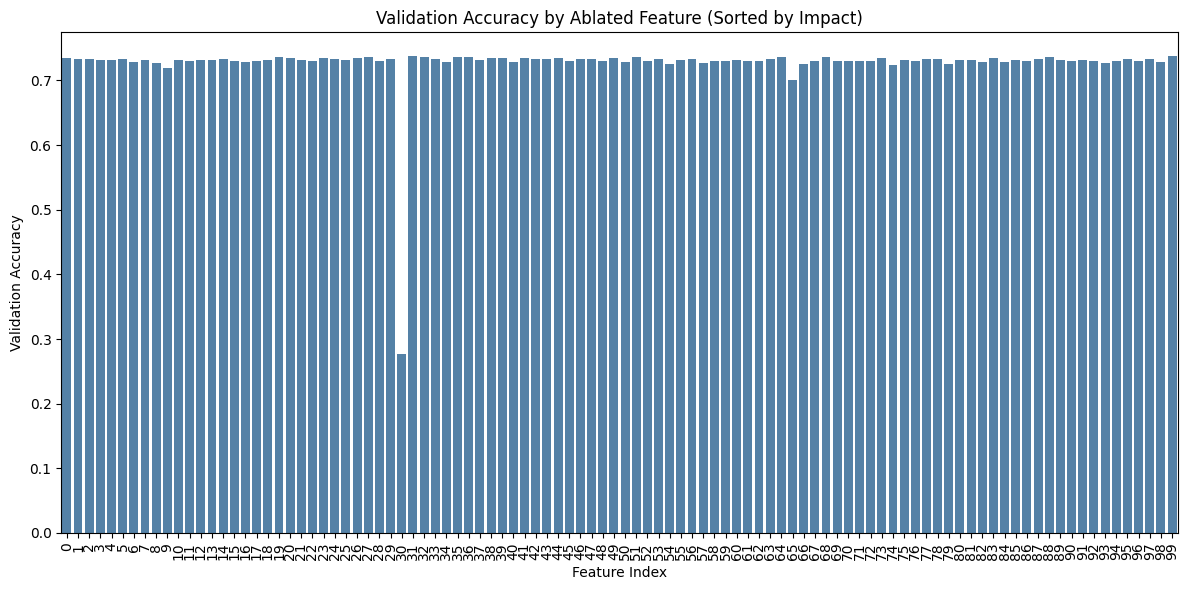


Top 10 Most Impactful Features (Lowest Accuracy When Ablated):
 feature_idx  accuracy
          30    0.2770
          65    0.7000
           9    0.7195
          74    0.7240
          54    0.7250
          79    0.7260
          66    0.7260
          93    0.7265
           8    0.7270
          57    0.7270


In [ ]:
# Ablate all features and visualize impact

print("\nEvaluating all features (0-99)...")
results = []

for feature_idx in tqdm(range(100)):
    val_acc, _, _ = evaluate_with_ablated_feature(
        model=model,
        sae=sae,
        act_mean=act_mean,
        feature_idx=feature_idx,
        dataloader=val_dl,
        layer_idx=0,
        sep_idx=SEP_TOKEN_INDEX,
        n_digits=N_DIGITS,
        device=DEVICE
    )
    results.append({"feature_idx": feature_idx, "accuracy": val_acc})

# Create DataFrame and sort by accuracy (lowest = most impactful)
df_accuracies = pd.DataFrame(results).sort_values("accuracy").reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_accuracies, x="feature_idx", y="accuracy", color="steelblue")
plt.xlabel("Feature Index")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Ablated Feature (Sorted by Impact)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Display most impactful features
print("\nTop 10 Most Impactful Features (Lowest Accuracy When Ablated):")
print(df_accuracies.head(10).to_string(index=False))

 Okay - so F30 reduces val accuracy to 27%,
 and the second worst to ablate is F54 which reduces val acc to 70% --> all other features hang around 70% !
 ==> F30 is defo carrying important info - but why are all the others 'equally' important?

In [ ]:
# CROSSOVER ANALYSIS: Load pre-computed results from GPU job
import ast

# Helper to parse list columns from CSV
def parse_list_column(df, col_name):
    """Parse string representation of lists back to actual lists."""
    df[col_name] = df[col_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

# Load crossovers
xovers_df = pd.read_csv(f'../results/xover/xovers_feat{SPECIAL_FEAT_IDX}.csv')
parse_list_column(xovers_df, 'o1_crossovers')
parse_list_column(xovers_df, 'o2_crossovers')

# Analyze crossover statistics
print(f"\nTotal inputs: {len(xovers_df)}")
print(f"Inputs with feature firing: {(xovers_df['feat_orig'] > 0).sum()}")
print(f"Inputs with no crossovers: {((xovers_df['n_o1_xover'] == 0) & (xovers_df['n_o2_xover'] == 0)).sum()}")
print(f"\nCrossover pattern distribution:")
print(xovers_df.groupby(['n_o1_xover', 'n_o2_xover']).size().to_frame('count'))

# Display sample of crossovers
print(f"\nSample of inputs with crossovers:")
display(xovers_df[xovers_df['n_o1_xover'] > 0].head(10))


Total inputs: 10000
Inputs with feature firing: 7054
Inputs with no crossovers: 3183

Crossover pattern distribution:
                       count
n_o1_xover n_o2_xover       
0          0            3183
           1             151
           2             241
1          0              61
           1             751
           2            5613

Sample of inputs with crossovers:


,d1,d2,feat_orig,o1_crossovers,o2_crossovers,o1_bound_types,o2_bound_types,n_o1_xover,n_o2_xover,scales,argmax_o1,argmax_o2,o1_failure_reason
1,28,90,2.367922,[0.3947],"[0.399, 3.942]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[90, 90, 90, 90, 90, 90, 90, 90, 28, 28, 28, 2...","[28, 28, 28, 28, 28, 28, 28, 28, 90, 90, 90, 9...",NaN
2,93,99,5.049258,[0.6262],"[0.22, 2.073]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 99, 9...","[93, 93, 93, 42, 48, 36, 46, 99, 99, 99, 99, 9...",NaN
3,19,17,1.157311,[1.7534],"[1.647, 8.523]",['lb'],"['lb', 'ub']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 1...","[68, 68, 68, 68, 47, 47, 47, 47, 47, 47, 17, 1...",NaN
4,49,19,1.844701,[2.1592],"[0.9, 4.259]",['lb'],"['lb', 'ub']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 49, 4...","[73, 73, 73, 76, 76, 76, 9, 9, 9, 9, 19, 19, 1...",NaN
5,17,29,4.622936,[0.6516],"[0.188, 2.09]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 2...","[17, 17, 88, 88, 45, 61, 92, 29, 29, 29, 29, 2...",NaN
6,4,29,3.016289,[0.2712],"[0.881, 1.726]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[29, 29, 29, 29, 29, 29, 4, 4, 4, 4, 4, 4, 4, ...","[79, 79, 90, 46, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...",NaN
8,3,37,2.022213,[0.6755],"[0.995, 4.421]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 3...","[34, 34, 34, 34, 34, 34, 34, 40, 40, 3, 3, 3, ...",NaN
9,82,23,4.708302,[0.455],"[0.271, 1.985]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 82, 8...","[82, 82, 82, 82, 27, 27, 27, 49, 23, 23, 23, 2...",NaN
14,55,92,2.788176,[0.4548],"[0.318, 3.053]",['ub'],"['ub', 'lb']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 55, 5...","[55, 55, 55, 55, 55, 55, 48, 92, 92, 92, 92, 9...",NaN
17,40,53,4.409449,[0.6783],"[1.106, 2.423]",['lb'],"['lb', 'ub']",1,2,"[0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.2...","[40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 4...","[70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 7...",NaN


 7054 have valid crossovers, and F30 firest on 7054 / 10k inputs
 - presumably these are the same set of inputs

In [ ]:
# SWAP BOUNDS: Load pre-computed swap zones
swap_bounds_df = pd.read_csv(f'../results/xover/swap_bounds_feat{SPECIAL_FEAT_IDX}.csv')

print(f"\nTotal inputs processed: {len(swap_bounds_df)}")
print(f"Valid swap zones found: {swap_bounds_df['failure_reason'].isna().sum()}")
print(f"\nFailure reason breakdown:")
print(swap_bounds_df['failure_reason'].value_counts())

# Display successful swap zones
valid_swaps = swap_bounds_df[swap_bounds_df['failure_reason'].isna()]
print(f"\nSwap zone statistics:")
print(f"Mean swap zone width: {valid_swaps['swap_zone_width'].mean():.3f}")
print(f"Median swap zone width: {valid_swaps['swap_zone_width'].median():.3f}")

print(f"\nSample of valid swap zones:")
display(valid_swaps.head(10))

invalid_swaps = swap_bounds_df[swap_bounds_df['lower_bound'].isna()]


Total inputs processed: 10000
Valid swap zones found: 6040

Failure reason breakdown:
failure_reason
feat_zero                    2946
o1_negative_scale             527
no_o2_crossover_in_bounds     198
o1_never_predicts_d2           88
d1_eq_d2                       83
no_o2_crossover                42
no_overlapping_dominance       42
o1_extrapolated                19
o2_never_predicts_d1           14
invalid_bounds                  1
Name: count, dtype: int64

Swap zone statistics:
Mean swap zone width: 1.266
Median swap zone width: 0.350

Sample of valid swap zones:


,d1,d2,lower_bound,upper_bound,midpoint,swap_zone_width,failure_reason
1,28,90,0.00,0.35,0.175,0.35,NaN
2,93,99,0.00,0.10,0.050,0.10,NaN
3,19,17,1.80,5.60,3.700,3.80,NaN
4,49,19,2.20,2.25,2.225,0.05,NaN
5,17,29,0.00,0.05,0.025,0.05,NaN
6,4,29,0.20,0.25,0.225,0.05,NaN
8,3,37,0.45,0.65,0.550,0.20,NaN
9,82,23,0.00,0.15,0.075,0.15,NaN
14,55,92,0.00,0.25,0.125,0.25,NaN
17,40,53,1.80,2.40,2.100,0.60,NaN


 so out of the 7054 inputs with xover, theres only 4023 valid swap zones? seems weird

In [ ]:
# VERIFY SWAPS: Load pre-computed swap verification results
swap_results_df = pd.read_csv(f'../results/xover/swap_results_feat{SPECIAL_FEAT_IDX}.csv')

# Analysis
total = len(swap_results_df)
swapped = swap_results_df['swapped'].sum()
print(f"\nSwap verification results:")
print(f"Total verified: {total}")
print(f"Successfully swapped: {swapped} ({swapped/total*100:.1f}%)")
print(f"Failed to swap: {total - swapped} ({(total-swapped)/total*100:.1f}%)")

# Show some examples
print(f"\nSuccessfully swapped examples:")
display(swap_results_df[swap_results_df['swapped']].head(5))

print(f"\nFailed to swap examples:")
display(swap_results_df[~swap_results_df['swapped']].head(5))


Swap verification results:
Total verified: 6040
Successfully swapped: 6040 (100.0%)
Failed to swap: 0 (0.0%)

Successfully swapped examples:


,d1,d2,scale,orig_o1,orig_o2,patched_o1,patched_o2,swapped
0,28,90,0.175,28,90,90,28,True
1,93,99,0.050,93,99,99,93,True
2,19,17,3.700,19,17,17,19,True
3,49,19,2.225,49,49,19,49,True
4,17,29,0.025,17,29,29,17,True



Failed to swap examples:


,d1,d2,scale,orig_o1,orig_o2,patched_o1,patched_o2,swapped


In [ ]:
invalid_swaps

,d1,d2,lower_bound,upper_bound,midpoint,swap_zone_width,failure_reason
0,60,44,NaN,NaN,NaN,NaN,o1_negative_scale
7,75,32,NaN,NaN,NaN,NaN,feat_zero
10,9,81,NaN,NaN,NaN,NaN,o1_negative_scale
11,48,69,NaN,NaN,NaN,NaN,feat_zero
12,7,84,NaN,NaN,NaN,NaN,feat_zero
...,...,...,...,...,...,...,...
9988,27,3,NaN,NaN,NaN,NaN,feat_zero
9991,96,48,NaN,NaN,NaN,NaN,feat_zero
9993,20,40,NaN,NaN,NaN,NaN,feat_zero
9996,69,69,NaN,NaN,NaN,NaN,d1_eq_d2


Using 3 specified input pairs


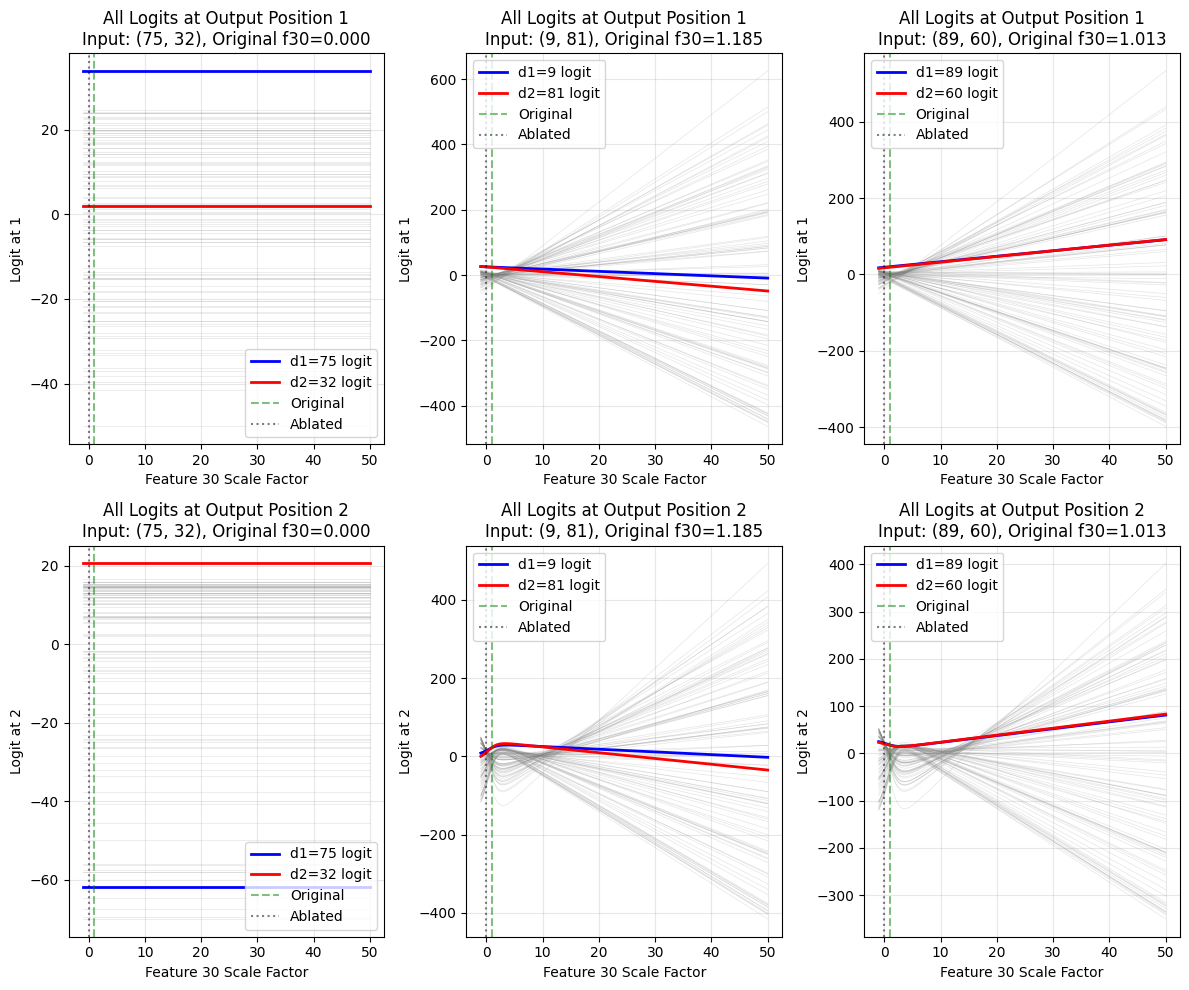


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (75, 32)
Original feature 30 activation: 0.0000
Original model output: (75, 32)

❌ O1: No crossover detected in range [-1.0, 50.0]
   d1 logit remains higher throughout

❌ O2: No crossover detected in range [-1.0, 50.0]
   d2 logit remains higher throughout

Test Case 2: Input (9, 81)
Original feature 30 activation: 1.1854
Original model output: (9, 81)

📍 O1: Found 1 crossover point(s)
   Crossover #1 at scale = -0.220 (3dp)
      d1 logit = 25.159, d2 logit = 25.183
      → Model output: (81, 5)

📍 O2: Found 2 crossover point(s)
   Crossover #1 at scale = 0.910 (3dp)
      d1 logit = 22.033, d2 logit = 21.992
      → Model output: (9, 9)
   Crossover #2 at scale = 8.633 (3dp)
      d1 logit = 26.371, d2 logit = 26.397
      → Model output: (70, 81)

Test Case 3: Input (89, 60)
Original feature 30 activation: 1.0130
Original model output: (89, 89)

📍 O1: Found 1 crossover point(s)
   Crossover #1 at scale = 36.647 (3dp)
      d1 l

In [ ]:
# test specific bad examples
# test_egs = [(93, 99), (38, 78)]
# test_egs = [(60,44), (75,32), (9,81), (32,75)]
# test_egs = [(4,29), (49,19), (19,17), (10,10)]
test_egs = [(75,32), (9,81), (89,60)]

results = feature_steering_experiment(
    model, sae, act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, 
    d2_all=d2_all, 
    sae_acts_all=sae_acts_all, 
    dataset=all_ds,
    scale_range=[-1.0, 50.0],
    test_pairs=test_egs
)

crossover_df = analyze_feature_crossovers(
    results=results,
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=SPECIAL_FEAT_IDX,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=SEP_TOKEN_INDEX,
    n_digits=N_DIGITS,
    device=DEVICE,
    verbose=True
)

In [ ]:
# Inspect outputs at custom scales (e.g., 2x feature activation)

# Test the egs at different scales
for d1_val, d2_val in test_egs:
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    idx = torch.where(mask)[0][0].item()
    inputs_i = all_ds[idx][0].unsqueeze(0).to(DEVICE)
    z_orig = sae_acts_all[idx].clone().to(DEVICE)
    feat_orig = z_orig[SPECIAL_FEAT_IDX].item()
    
    print(f"\n{'='*60}")
    print(f"Input: ({d1_val}, {d2_val}), Original feature {SPECIAL_FEAT_IDX}: {feat_orig:.4f}")
    print(f"{'='*60}")
    
    # Inspect at multiple scales
    custom_scales = [-1.0, 0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 3.0, 5.0]
    # custom_scales = [2.2,2.3]
    result_list, df = inspect_steered_outputs_batch(
        model=model, sae=sae, act_mean=act_mean,
        feature_idx=SPECIAL_FEAT_IDX,
        scales=custom_scales,
        inputs_i=inputs_i, z_orig=z_orig, feat_orig=feat_orig,
        d1_val=d1_val, d2_val=d2_val,
        layer_idx=0, sep_idx=SEP_TOKEN_INDEX, n_digits=N_DIGITS,
        device=DEVICE
    )
    print(df.to_string(index=False))


Input: (75, 32), Original feature 30: 0.0000
 scale  pred_o1  pred_o2  d1_logit_o1  d2_logit_o1  d1_logit_o2  d2_logit_o2
  -1.0       75       32    33.868431     2.006443   -61.791702    20.638939
   0.0       75       32    33.868431     2.006443   -61.791702    20.638939
   0.5       75       32    33.868431     2.006443   -61.791702    20.638939
   1.0       75       32    33.868431     2.006443   -61.791702    20.638939
   1.5       75       32    33.868431     2.006443   -61.791702    20.638939
   2.0       75       32    33.868431     2.006443   -61.791702    20.638939
   2.2       75       32    33.868431     2.006443   -61.791702    20.638939
   3.0       75       32    33.868431     2.006443   -61.791702    20.638939
   5.0       75       32    33.868431     2.006443   -61.791702    20.638939

Input: (9, 81), Original feature 30: 1.1854
 scale  pred_o1  pred_o2  d1_logit_o1  d2_logit_o1  d1_logit_o2  d2_logit_o2
  -1.0       81       18    25.676918    26.290487     8.62284

In [ ]:
# get input pairs that F30 doesn't activate for
inactive_mask = sae_acts_all[:, SPECIAL_FEAT_IDX] == 0
inactive_d1 = d1_all[inactive_mask].cpu().numpy()
inactive_d2 = d2_all[inactive_mask].cpu().numpy()
inactive_pairs = set(zip(inactive_d1, inactive_d2)) 

print(f"Number of inactive pairs for feature {SPECIAL_FEAT_IDX}: {len(inactive_pairs)}")
print(f"Sample inactive pairs: {list(inactive_pairs)}")

Number of inactive pairs for feature 30: 2946
Sample inactive pairs: [(26, 21), (24, 97), (50, 6), (63, 25), (36, 71), (42, 2), (83, 3), (90, 42), (29, 32), (92, 88), (52, 15), (50, 91), (83, 39), (29, 68), (75, 35), (95, 13), (41, 42), (87, 9), (52, 51), (25, 34), (64, 25), (56, 21), (22, 28), (54, 97), (46, 13), (4, 96), (97, 58), (49, 18), (35, 83), (36, 48), (7, 21), (46, 98), (36, 84), (83, 16), (29, 45), (75, 12), (48, 58), (80, 90), (33, 15), (52, 28), (25, 11), (64, 2), (10, 31), (62, 78), (22, 5), (74, 52), (25, 47), (12, 77), (45, 25), (65, 3), (23, 86), (97, 35), (35, 60), (96, 76), (26, 11), (24, 87), (90, 32), (63, 15), (9, 44), (48, 35), (94, 2), (92, 78), (52, 5), (10, 8), (42, 77), (75, 25), (62, 55), (41, 32), (54, 51), (27, 97), (33, 28), (45, 2), (64, 15), (10, 44), (56, 11), (62, 91), (22, 18), (95, 88), (74, 65), (20, 94), (13, 55), (4, 86), (79, 0), (24, 64), (43, 77), (90, 9), (35, 73), (96, 89), (7, 11), (88, 85), (99, 94), (46, 88), (92, 55), (57, 97), (63, 28)

 (75,32) doesnt activate F30, but (32,75) does - is this weird?
 Model learns an attn pattern for 75,32 input, which needn't be same as input 32,75
 ==> makes sense that swapping behaviour controlled by attn pattern wouldn't be necc related

 So we have (out of 10k inputs):
 - 5596 inputs activate F30 & swap predictably (56%)
 - 2946 don't activate F30 at all (29%)
 - 1458 (i.e. the rest) activate F30 but don't have valid swap zones (15%)
   eg. no xover for o1 and/or o2, or some other error
 Looking at that 15% without

In [ ]:
# CROSSOVER ANALYSIS FILTERED BY ORIGINAL PREDICTION CORRECTNESS
# Run baseline inference on all inputs to get ground-truth correctness per example,
# then join onto swap_results_df (which only covers inputs that had a valid swap zone).
# This avoids relying on derived columns from xovers_df that may be unreliable,
# and sidesteps duplicate-(d1,d2) issues in the merge.

model.eval()
_rows = []
_offset = 0
with torch.no_grad():
    for batch in all_dl:
        inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
        bsz = inputs.shape[0]
        logits = model(inputs)
        pred_o1 = logits[:, -2, :N_DIGITS].argmax(dim=-1).cpu()
        pred_o2 = logits[:, -1, :N_DIGITS].argmax(dim=-1).cpu()
        tgt_o1  = targets[:, -2].cpu()
        tgt_o2  = targets[:, -1].cpu()
        correct = ((pred_o1 == tgt_o1) & (pred_o2 == tgt_o2)).int()
        d1_batch = d1_all[_offset : _offset + bsz].cpu()
        d2_batch = d2_all[_offset : _offset + bsz].cpu()
        _rows.append(torch.stack([d1_batch, d2_batch, correct], dim=1))
        _offset += bsz

# Build a (d1, d2) -> correct lookup; use majority vote for any repeated pairs
_pred_df = pd.DataFrame(torch.cat(_rows).numpy(), columns=['d1', 'd2', 'correct'])
_pred_df = _pred_df.astype(int)
correctness_lookup = (
    _pred_df.groupby(['d1', 'd2'])['correct']
    .mean()                     # fraction of times this pair was correct
    .ge(0.5)                    # True if correct on the majority of occurrences
    .reset_index()
    .rename(columns={'correct': 'orig_correct'})
)

# Join correctness onto swap_results_df (one row per successfully-swapped input)
sr = swap_results_df.merge(correctness_lookup, on=['d1', 'd2'], how='left')

# Join correctness onto swap_bounds_df to cover ALL inputs that went into the pipeline
# (including those that failed to find a swap zone)
sb = swap_bounds_df.merge(correctness_lookup, on=['d1', 'd2'], how='left')
sb['swapped'] = sb['failure_reason'].isna()   # valid swap zone ≈ successfully swapped

def swap_summary_full(df, label):
    total = len(df)
    swapped = int(df['swapped'].sum())
    pct = swapped / total * 100 if total > 0 else 0.0
    print(f"{label}")
    print(f"  n={total:>5}  |  swapped: {swapped:>5} ({pct:.1f}%)")

print("Swap success rate (out of all inputs processed in the crossover pipeline)")
print("by whether the model's *original* (unsteered) prediction was correct")
print("=" * 65)
swap_summary_full(sb[sb['orig_correct']],  "Originally CORRECT  ")
swap_summary_full(sb[~sb['orig_correct']], "Originally INCORRECT")
swap_summary_full(sb,                      "All pipeline inputs (combined)")

Swap success rate (out of all inputs processed in the crossover pipeline)
by whether the model's *original* (unsteered) prediction was correct
Originally CORRECT  
  n= 9118  |  swapped:  5731 (62.9%)
Originally INCORRECT
  n=  882  |  swapped:   309 (35.0%)
All pipeline inputs (combined)
  n=10000  |  swapped:  6040 (60.4%)
